In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(
    "ott_viewer_dropoff_retention_us_v1.0.csv"
)

In [4]:
df

,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016,1,1,48,4,5,...,39,3,0,0,9,high,0,1,0.649,high
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016,1,2,55,5,4,...,55,3,3,1,5,medium,0,0,0.473,medium
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016,1,3,51,4,8,...,46,4,2,0,9,high,0,0,0.583,medium
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016,1,4,50,4,7,...,50,4,1,0,7,high,0,0,0.520,medium
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016,1,5,52,4,3,...,35,3,0,1,7,high,0,1,0.638,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33166,4616,Xena: Warrior Princess,Prime Video,Drama,1995,1,20,44,3,5,...,48,4,0,1,7,high,0,0,0.559,medium
33167,4616,Xena: Warrior Princess,Prime Video,Drama,1995,1,21,44,6,4,...,45,2,4,1,7,high,0,0,0.568,medium
33168,4616,Xena: Warrior Princess,Prime Video,Drama,1995,1,22,44,4,5,...,42,2,4,1,9,high,0,1,0.626,high
33169,4616,Xena: Warrior Princess,Prime Video,Drama,1995,1,23,44,6,4,...,45,3,1,1,7,high,0,0,0.578,medium


In [5]:
df.shape


(33171, 22)

In [6]:
df.head()

,show_id,title,platform,genre,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,...,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,attention_required,night_watch_safe,drop_off,drop_off_probability,retention_risk
0,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016,1,1,48,4,5,...,39,3,0,0,9,high,0,1,0.649,high
1,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016,1,2,55,5,4,...,55,3,3,1,5,medium,0,0,0.473,medium
2,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016,1,3,51,4,8,...,46,4,2,0,9,high,0,0,0.583,medium
3,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016,1,4,50,4,7,...,50,4,1,0,7,high,0,0,0.520,medium
4,66732,Stranger Things,Netflix,Sci-Fi & Fantasy,2016,1,5,52,4,3,...,35,3,0,1,7,high,0,1,0.638,high


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33171 entries, 0 to 33170
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   show_id               33171 non-null  int64  
 1   title                 33171 non-null  object 
 2   platform              33171 non-null  object 
 3   genre                 33171 non-null  object 
 4   release_year          33171 non-null  int64  
 5   season_number         33171 non-null  int64  
 6   episode_number        33171 non-null  int64  
 7   episode_duration_min  33171 non-null  int64  
 8   pacing_score          33171 non-null  int64  
 9   hook_strength         33171 non-null  int64  
 10  dialogue_density      33171 non-null  object 
 11  visual_intensity      33171 non-null  int64  
 12  avg_watch_percentage  33171 non-null  int64  
 13  pause_count           33171 non-null  int64  
 14  rewind_count          33171 non-null  int64  
 15  skip_intro         

In [8]:
df.describe()

,show_id,release_year,season_number,episode_number,episode_duration_min,pacing_score,hook_strength,visual_intensity,avg_watch_percentage,pause_count,rewind_count,skip_intro,cognitive_load,night_watch_safe,drop_off,drop_off_probability
count,33171.000000,33171.000000,33171.0,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000,33171.000000
mean,63698.539688,2000.739743,1.0,423.718881,37.660667,5.397908,5.525158,6.009436,56.805764,3.102921,2.003497,0.493262,6.196015,0.015887,0.144825,0.478433
std,65206.256887,15.750470,0.0,557.688460,22.899741,1.230418,1.730098,1.994370,12.577000,1.866938,1.548391,0.499962,1.322146,0.125042,0.351930,0.107382
min,36.000000,1952.000000,1.0,1.000000,1.000000,3.000000,3.000000,3.000000,13.000000,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.120000
25%,15226.000000,1992.000000,1.0,27.000000,24.000000,4.000000,4.000000,4.000000,48.000000,2.000000,1.000000,0.000000,5.000000,0.000000,0.000000,0.400000
50%,35024.000000,2004.000000,1.0,178.000000,33.000000,5.000000,6.000000,6.000000,57.000000,3.000000,2.000000,0.000000,7.000000,0.000000,0.000000,0.471000
75%,80885.000000,2012.000000,1.0,611.000000,49.000000,6.000000,7.000000,8.000000,66.000000,4.000000,3.000000,1.000000,7.000000,0.000000,0.000000,0.553000
max,305062.000000,2025.000000,1.0,2650.000000,1225.000000,8.000000,10.000000,9.000000,100.000000,10.000000,8.000000,1.000000,9.000000,1.000000,1.000000,0.831000


In [9]:
df.columns

Index(['show_id', 'title', 'platform', 'genre', 'release_year',
       'season_number', 'episode_number', 'episode_duration_min',
       'pacing_score', 'hook_strength', 'dialogue_density', 'visual_intensity',
       'avg_watch_percentage', 'pause_count', 'rewind_count', 'skip_intro',
       'cognitive_load', 'attention_required', 'night_watch_safe', 'drop_off',
       'drop_off_probability', 'retention_risk'],
      dtype='object')

In [10]:
df.isnull().sum() #count missing values

show_id                 0
title                   0
platform                0
genre                   0
release_year            0
season_number           0
episode_number          0
episode_duration_min    0
pacing_score            0
hook_strength           0
dialogue_density        0
visual_intensity        0
avg_watch_percentage    0
pause_count             0
rewind_count            0
skip_intro              0
cognitive_load          0
attention_required      0
night_watch_safe        0
drop_off                0
drop_off_probability    0
retention_risk          0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
for col in df.columns:
    print(col)
    print(df[col].nunique())

show_id
489
title
487
platform
28
genre
16
release_year
65
season_number
1
episode_number
2650
episode_duration_min
154
pacing_score
6
hook_strength
8
dialogue_density
3
visual_intensity
7
avg_watch_percentage
84
pause_count
11
rewind_count
9
skip_intro
2
cognitive_load
5
attention_required
2
night_watch_safe
2
drop_off
2
drop_off_probability
610
retention_risk
3


In [13]:
df['night_watch_safe'].value_counts()

night_watch_safe
0    32644
1      527
Name: count, dtype: int64

In [14]:
pd.crosstab(
    df['night_watch_safe'],
    df['drop_off'],
    normalize='index'
)

drop_off,0,1
night_watch_safe,,
0,0.852837,0.147163
1,1.000000,0.000000


In [15]:
df['drop_off'].value_counts()

drop_off
0    28367
1     4804
Name: count, dtype: int64

In [16]:
(df['drop_off'].value_counts(normalize=True)*100)

drop_off
0    85.51747
1    14.48253
Name: proportion, dtype: float64

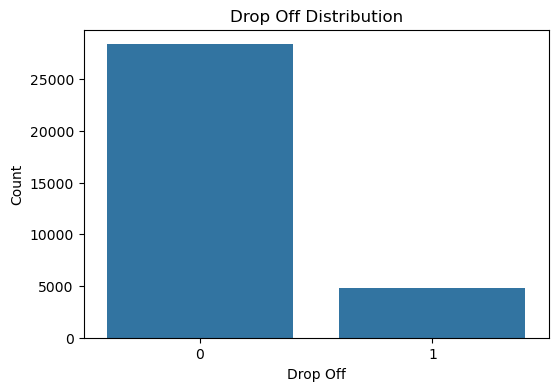

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x='drop_off',data=df)

plt.title('Drop Off Distribution')
plt.xlabel('Drop Off')
plt.ylabel('Count')

plt.show()

In [18]:
num_cols = [
    'release_year',
    'season_number',
    'episode_number',
    'episode_duration_min',
    'pacing_score',
    'hook_strength',
    'visual_intensity',
    'avg_watch_percentage',
    'pause_count',
    'rewind_count',
    'cognitive_load',
    'skip_intro'
]

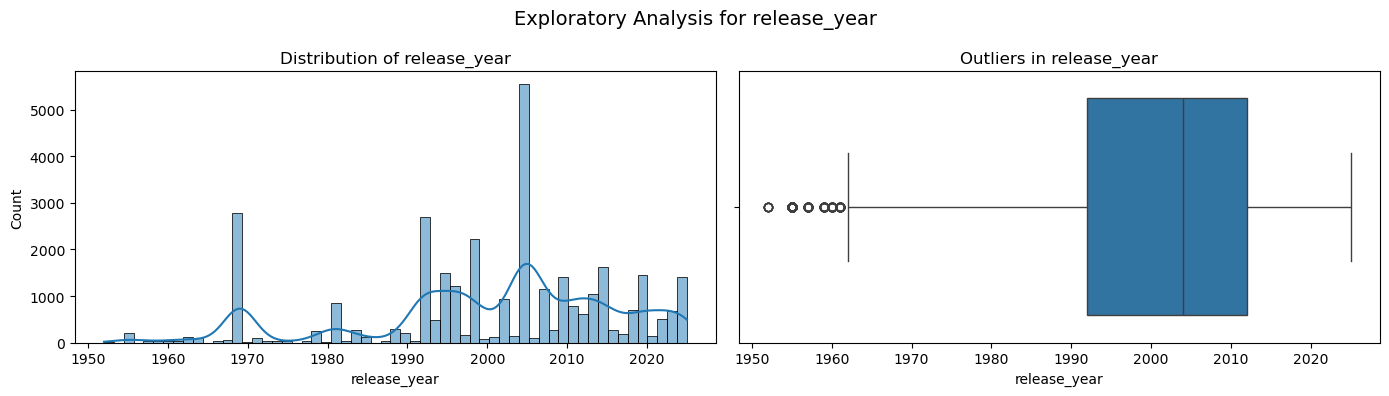

Feature           : release_year
Q1                : 1992.00
Q3                : 2012.00
IQR               : 20.00
Lower Bound       : 1962.00
Upper Bound       : 2042.00
Outlier Count     : 351
Outlier Percent   : 1.06%
Unique Outlier Values:
[np.int64(1952), np.int64(1955), np.int64(1957), np.int64(1959), np.int64(1960), np.int64(1961)]




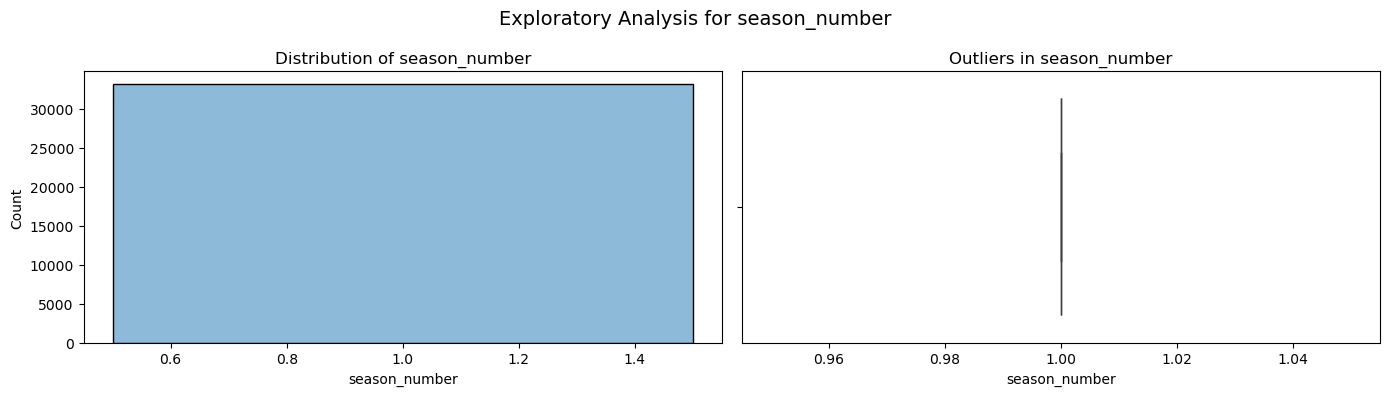

Feature           : season_number
Q1                : 1.00
Q3                : 1.00
IQR               : 0.00
Lower Bound       : 1.00
Upper Bound       : 1.00
Outlier Count     : 0
Outlier Percent   : 0.00%




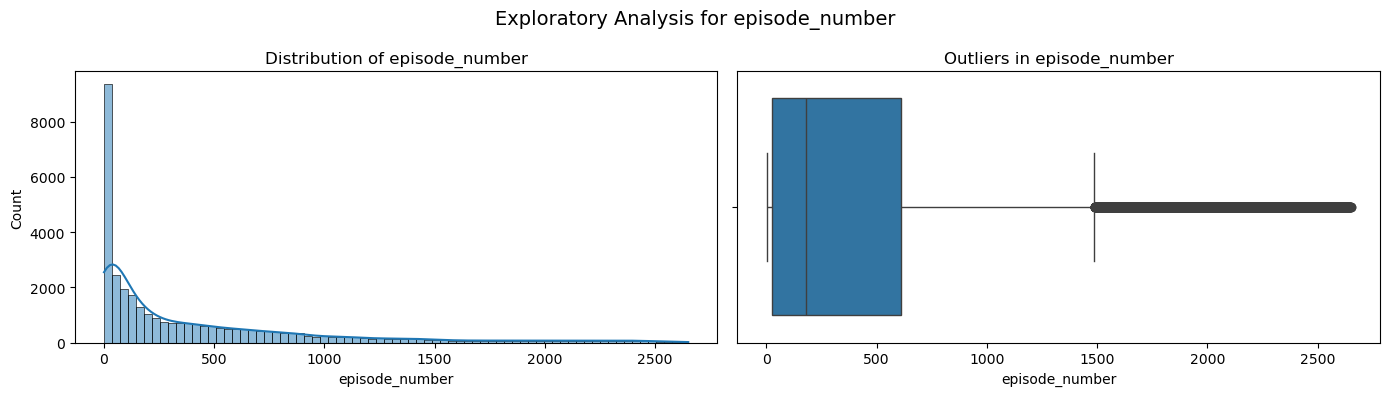

Feature           : episode_number
Q1                : 27.00
Q3                : 611.00
IQR               : 584.00
Lower Bound       : -849.00
Upper Bound       : 1487.00
Outlier Count     : 2211
Outlier Percent   : 6.67%
Unique Outlier Values:
[np.int64(1488), np.int64(1489), np.int64(1490), np.int64(1491), np.int64(1492), np.int64(1493), np.int64(1494), np.int64(1495), np.int64(1496), np.int64(1497), np.int64(1498), np.int64(1499), np.int64(1500), np.int64(1501), np.int64(1502), np.int64(1503), np.int64(1504), np.int64(1505), np.int64(1506), np.int64(1507)]




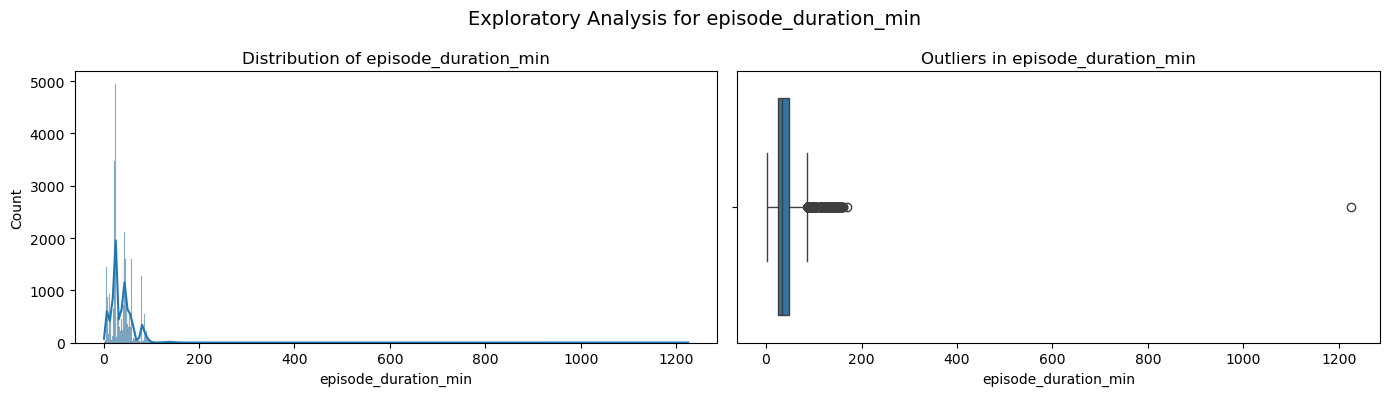

Feature           : episode_duration_min
Q1                : 24.00
Q3                : 49.00
IQR               : 25.00
Lower Bound       : -13.50
Upper Bound       : 86.50
Outlier Count     : 852
Outlier Percent   : 2.57%
Unique Outlier Values:
[np.int64(87), np.int64(88), np.int64(89), np.int64(90), np.int64(91), np.int64(92), np.int64(93), np.int64(94), np.int64(95), np.int64(96), np.int64(97), np.int64(98), np.int64(99), np.int64(100), np.int64(101), np.int64(102), np.int64(103), np.int64(107), np.int64(108), np.int64(112)]




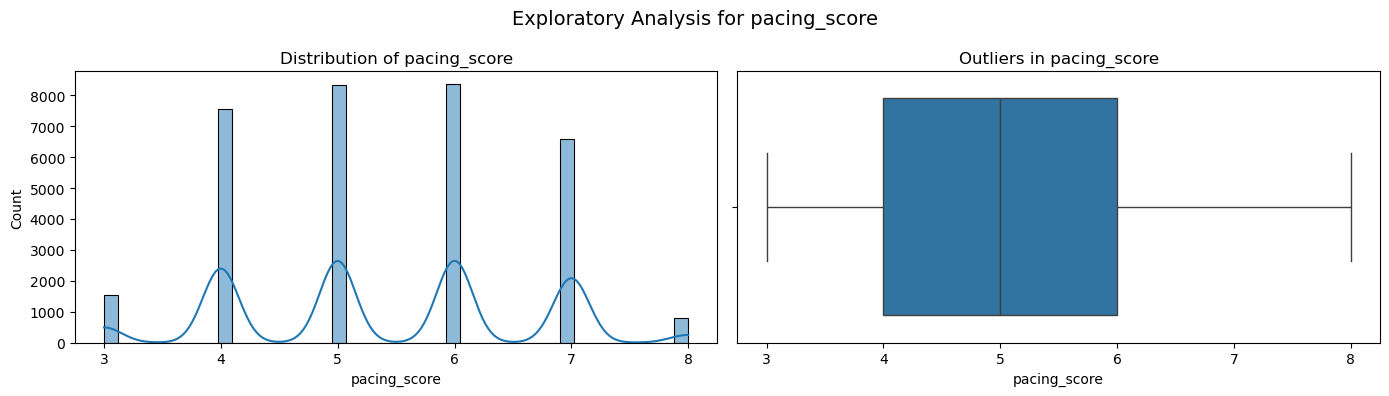

Feature           : pacing_score
Q1                : 4.00
Q3                : 6.00
IQR               : 2.00
Lower Bound       : 1.00
Upper Bound       : 9.00
Outlier Count     : 0
Outlier Percent   : 0.00%




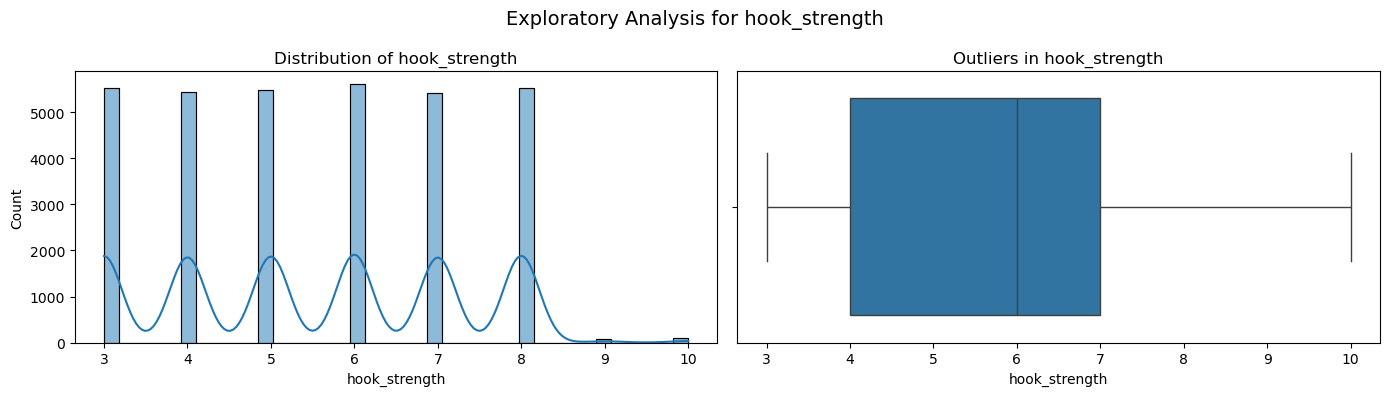

Feature           : hook_strength
Q1                : 4.00
Q3                : 7.00
IQR               : 3.00
Lower Bound       : -0.50
Upper Bound       : 11.50
Outlier Count     : 0
Outlier Percent   : 0.00%




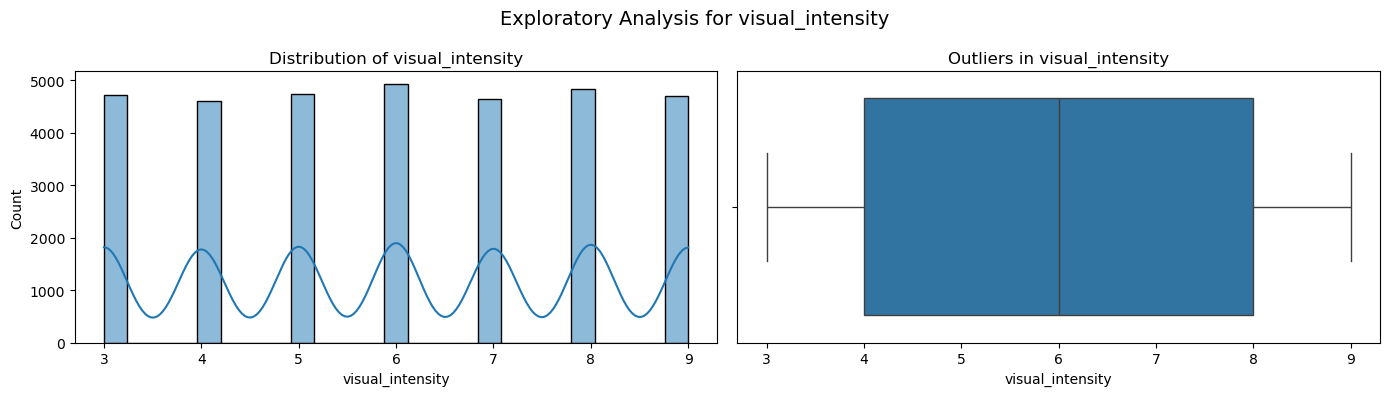

Feature           : visual_intensity
Q1                : 4.00
Q3                : 8.00
IQR               : 4.00
Lower Bound       : -2.00
Upper Bound       : 14.00
Outlier Count     : 0
Outlier Percent   : 0.00%




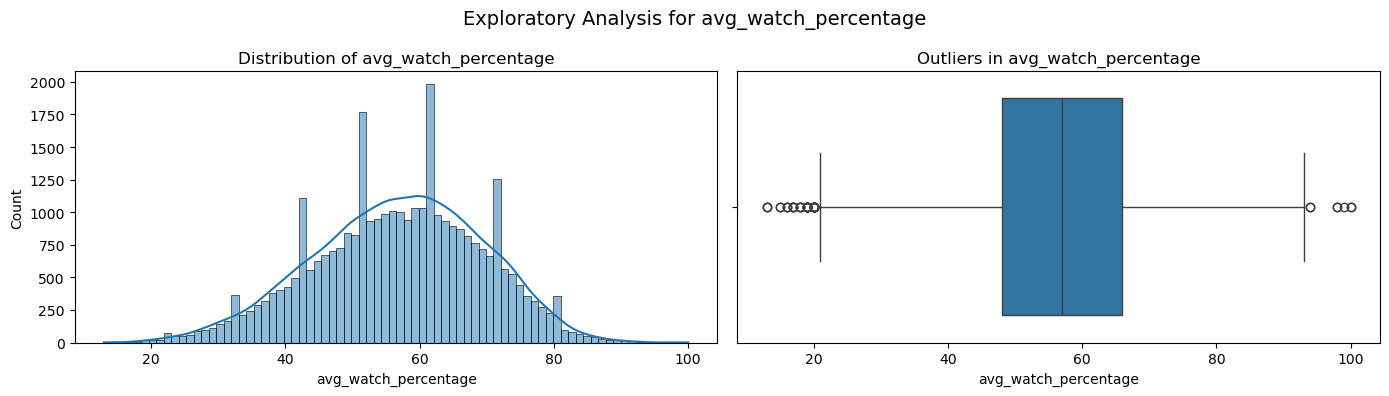

Feature           : avg_watch_percentage
Q1                : 48.00
Q3                : 66.00
IQR               : 18.00
Lower Bound       : 21.00
Upper Bound       : 93.00
Outlier Count     : 61
Outlier Percent   : 0.18%
Unique Outlier Values:
[np.int64(13), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(94), np.int64(98), np.int64(99), np.int64(100)]




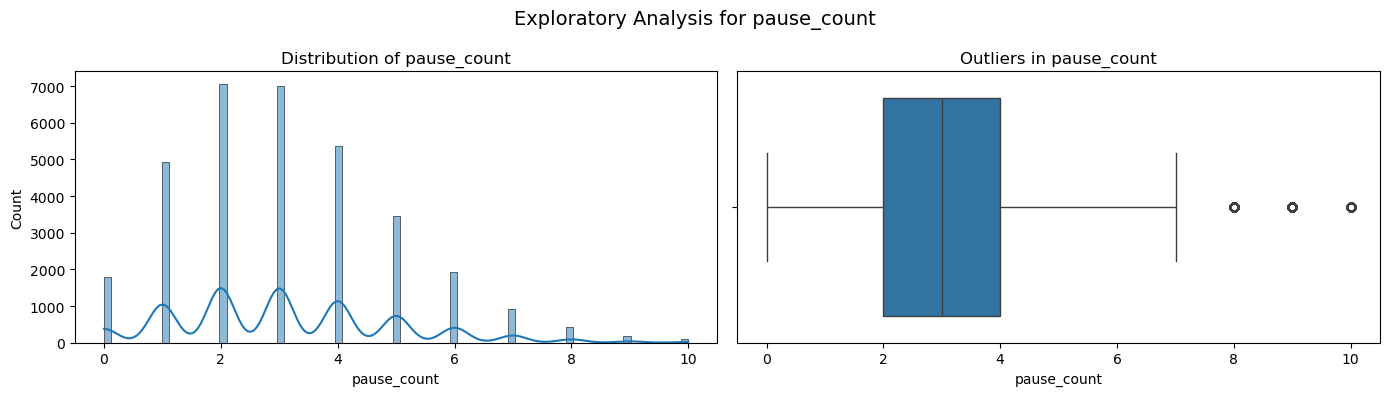

Feature           : pause_count
Q1                : 2.00
Q3                : 4.00
IQR               : 2.00
Lower Bound       : -1.00
Upper Bound       : 7.00
Outlier Count     : 698
Outlier Percent   : 2.10%
Unique Outlier Values:
[np.int64(8), np.int64(9), np.int64(10)]




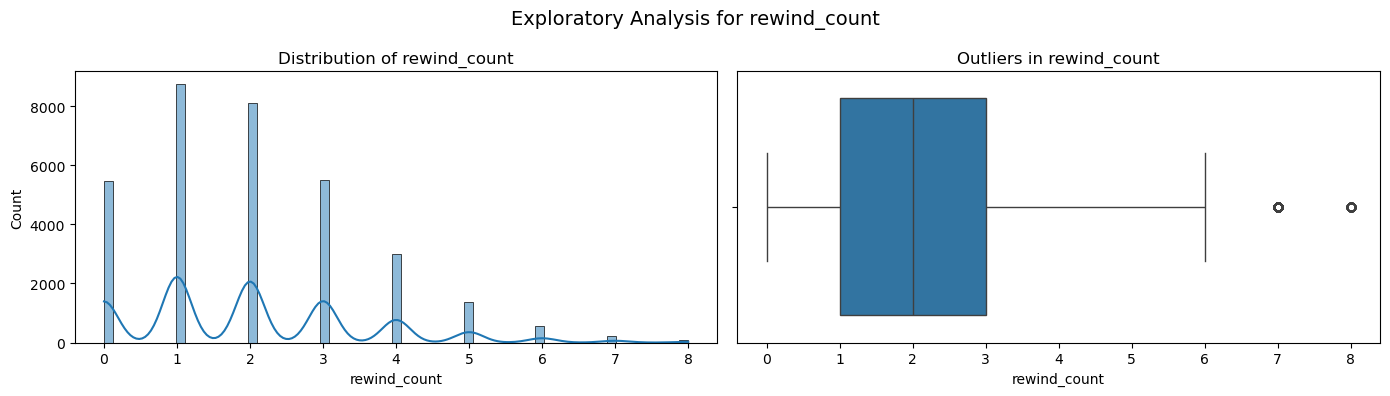

Feature           : rewind_count
Q1                : 1.00
Q3                : 3.00
IQR               : 2.00
Lower Bound       : -2.00
Upper Bound       : 6.00
Outlier Count     : 340
Outlier Percent   : 1.02%
Unique Outlier Values:
[np.int64(7), np.int64(8)]




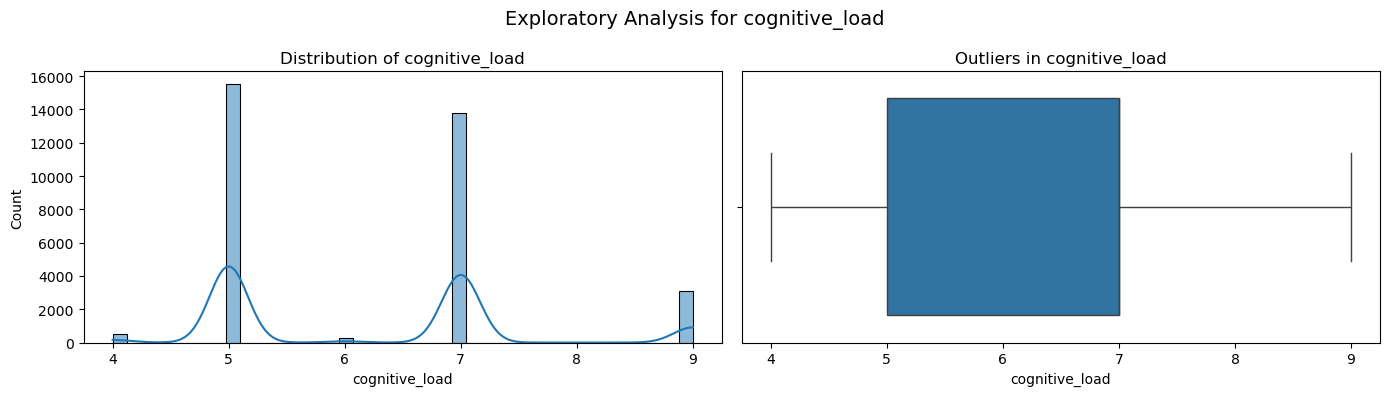

Feature           : cognitive_load
Q1                : 5.00
Q3                : 7.00
IQR               : 2.00
Lower Bound       : 2.00
Upper Bound       : 10.00
Outlier Count     : 0
Outlier Percent   : 0.00%




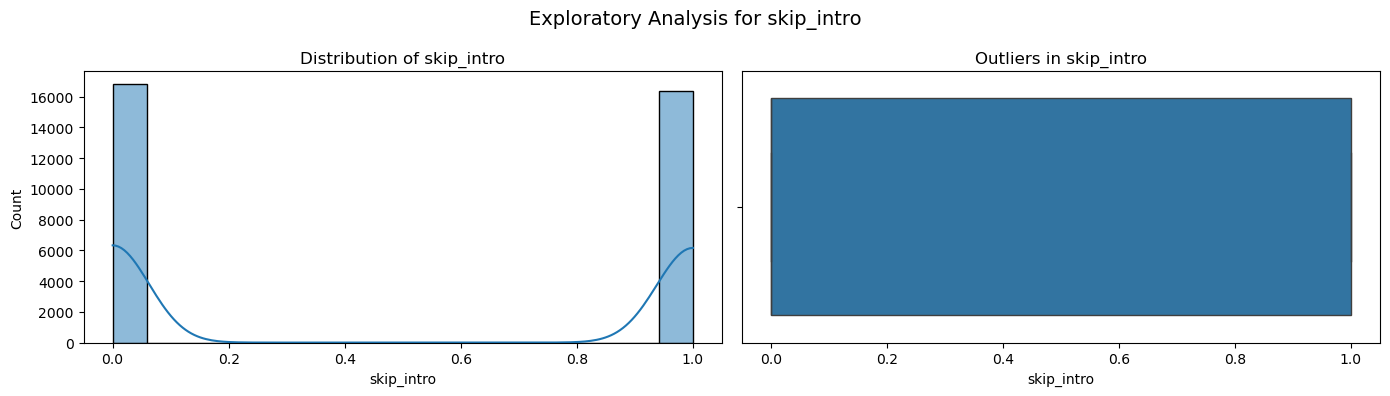

Feature           : skip_intro
Q1                : 0.00
Q3                : 1.00
IQR               : 1.00
Lower Bound       : -1.50
Upper Bound       : 2.50
Outlier Count     : 0
Outlier Percent   : 0.00%




In [19]:
for col in num_cols:

    # IQR calculation
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outliers = df[(df[col] < lower_bound) |(df[col] > upper_bound)][col]

    # Visualization
    fig, ax = plt.subplots(1, 2, figsize=(14,4))

    sns.histplot(data=df, x=col, kde=True, ax=ax[0])
    ax[0].set_title(f'Distribution of {col}')

    sns.boxplot(data=df, x=col, ax=ax[1])
    ax[1].set_title(f'Outliers in {col}')

    plt.suptitle(f'Exploratory Analysis for {col}', fontsize=14)
    plt.tight_layout()
    plt.show()

    # Statistics
    print('='*70)
    print(f'Feature           : {col}')
    print(f'Q1                : {Q1:.2f}')
    print(f'Q3                : {Q3:.2f}')
    print(f'IQR               : {IQR:.2f}')
    print(f'Lower Bound       : {lower_bound:.2f}')
    print(f'Upper Bound       : {upper_bound:.2f}')

    print(f'Outlier Count     : {len(outliers)}')
    print(f'Outlier Percent   : {(len(outliers)/len(df))*100:.2f}%')

    if len(outliers) > 0:
        print('Unique Outlier Values:')
        print(sorted(outliers.unique())[:20])

    print('\n')

In [20]:
df['season_number'].value_counts()

season_number
1    33171
Name: count, dtype: int64

In [21]:
cat_cols = [
    'platform',
    'genre',
    'dialogue_density',
    'attention_required',
    'retention_risk'
]

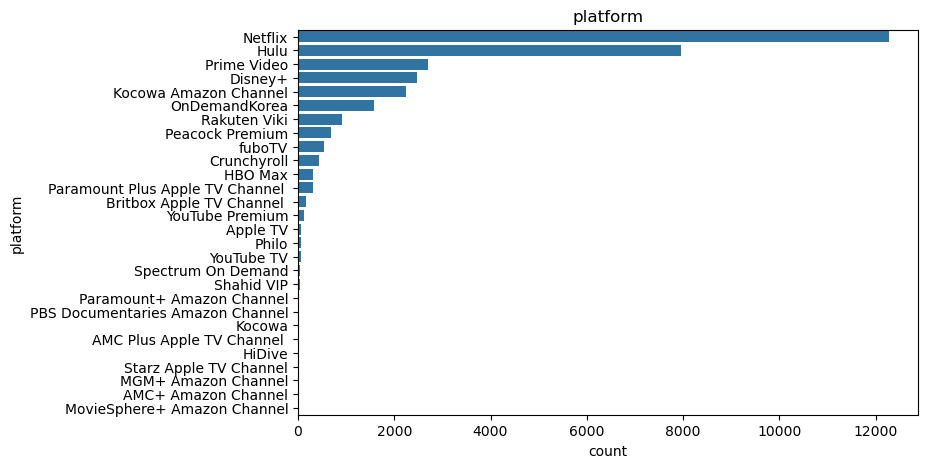

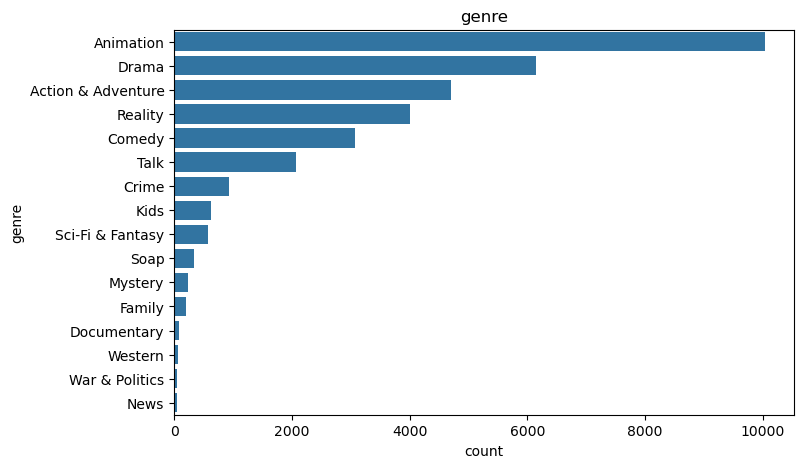

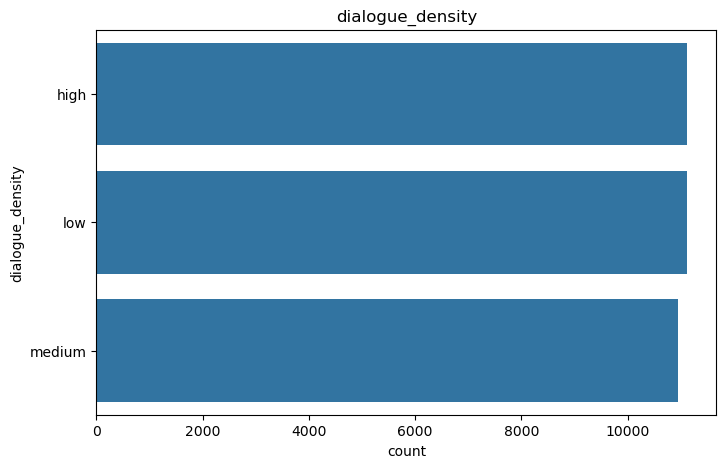

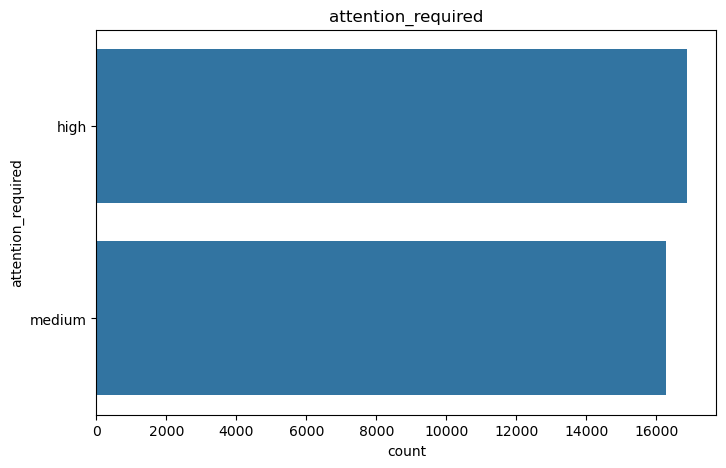

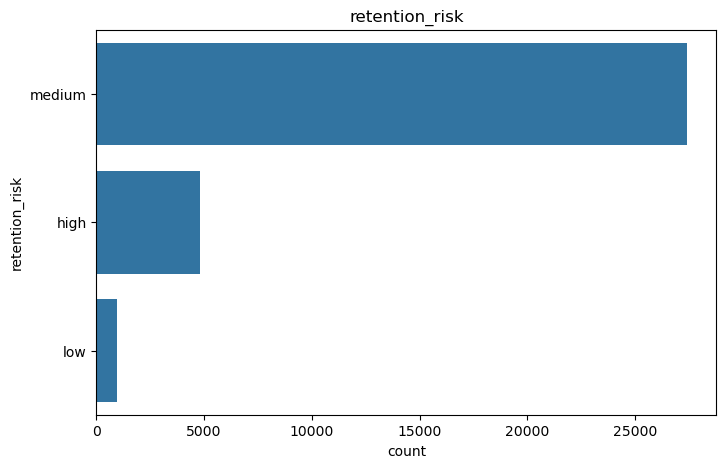

In [22]:
for col in cat_cols:

    plt.figure(figsize=(8,5))
    sns.countplot(y=df[col],order=df[col].value_counts().index)
    plt.title(col)
    plt.show()

In [23]:
df.drop('season_number', axis=1, inplace=True) # contain only one unique value

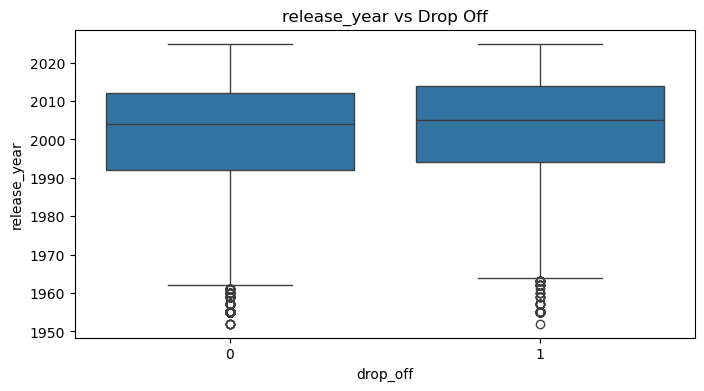



release_year
            count         mean        std     min     25%     50%     75%  \
drop_off                                                                    
0         28367.0  2000.568160  15.695213  1952.0  1992.0  2004.0  2012.0   
1          4804.0  2001.752914  16.037158  1952.0  1994.0  2005.0  2014.0   

             max  
drop_off          
0         2025.0  
1         2025.0  


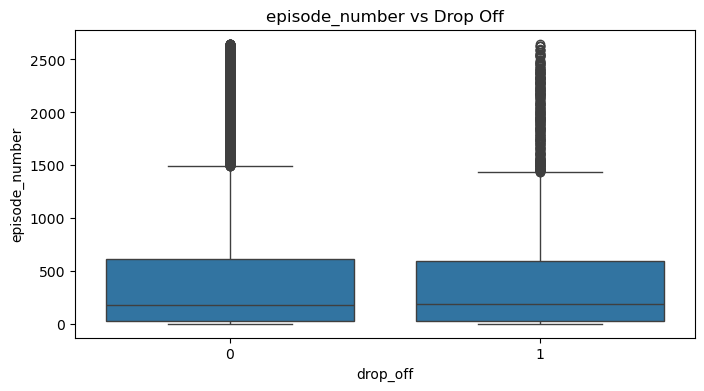



episode_number
            count        mean         std  min   25%    50%    75%     max
drop_off                                                                  
0         28367.0  425.712095  560.034666  1.0  27.0  178.0  614.0  2650.0
1          4804.0  411.949209  543.536104  1.0  24.0  182.0  589.0  2643.0


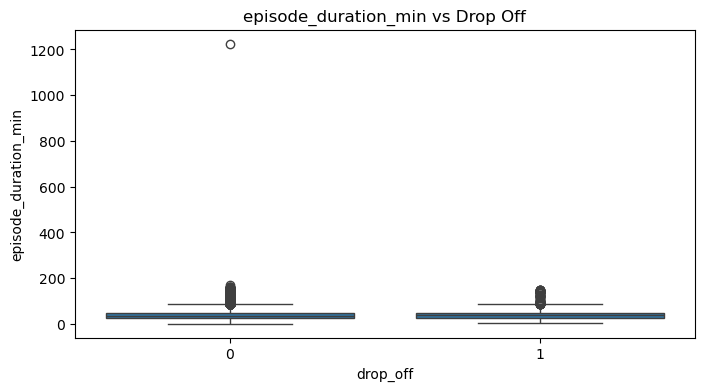



episode_duration_min
            count       mean        std  min   25%   50%   75%     max
drop_off                                                              
0         28367.0  37.660979  23.275510  1.0  24.0  32.0  49.0  1225.0
1          4804.0  37.658826  20.543438  4.0  24.0  37.0  49.0   149.0


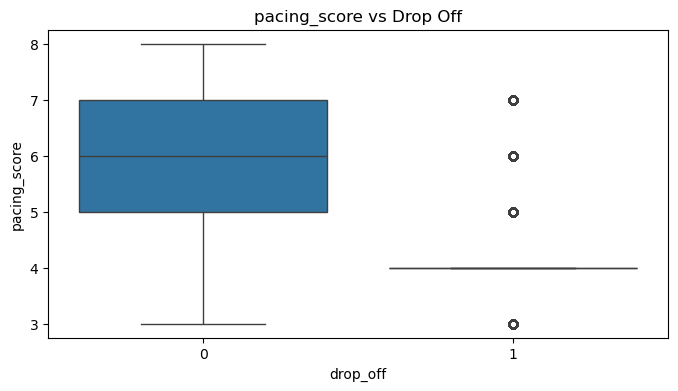



pacing_score
            count      mean       std  min  25%  50%  75%  max
drop_off                                                      
0         28367.0  5.607502  1.157302  3.0  5.0  6.0  7.0  8.0
1          4804.0  4.160283  0.868226  3.0  4.0  4.0  4.0  7.0


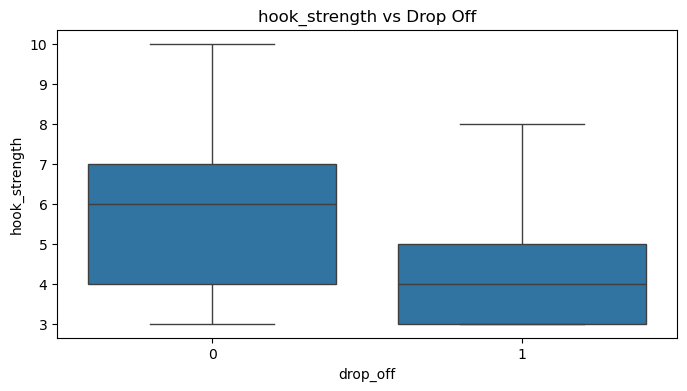



hook_strength
            count      mean       std  min  25%  50%  75%   max
drop_off                                                       
0         28367.0  5.741989  1.684301  3.0  4.0  6.0  7.0  10.0
1          4804.0  4.244796  1.414222  3.0  3.0  4.0  5.0   8.0


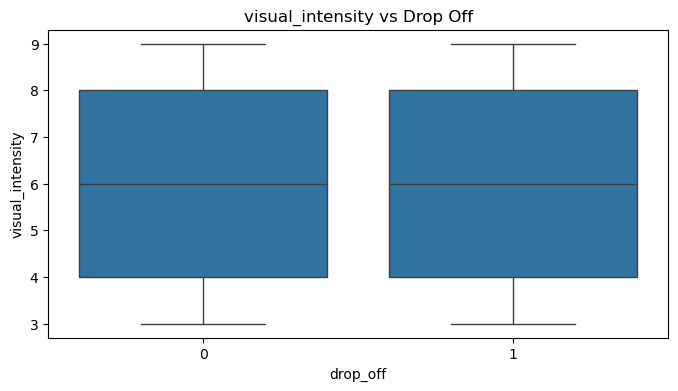



visual_intensity
            count      mean       std  min  25%  50%  75%  max
drop_off                                                      
0         28367.0  6.007015  1.993163  3.0  4.0  6.0  8.0  9.0
1          4804.0  6.023730  2.001628  3.0  4.0  6.0  8.0  9.0


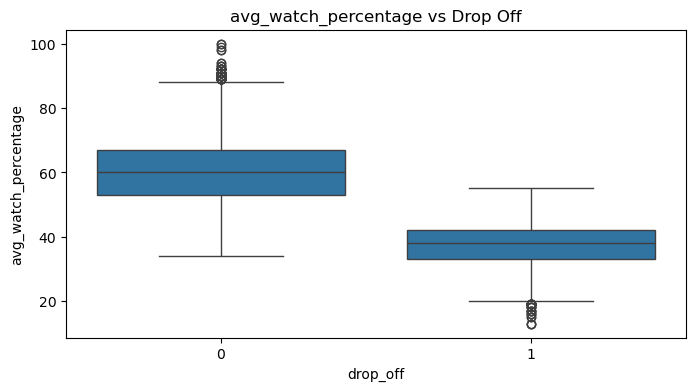



avg_watch_percentage
            count       mean        std   min   25%   50%   75%    max
drop_off                                                              
0         28367.0  60.145909  10.054907  34.0  53.0  60.0  67.0  100.0
1          4804.0  37.082639   6.351889  13.0  33.0  38.0  42.0   55.0


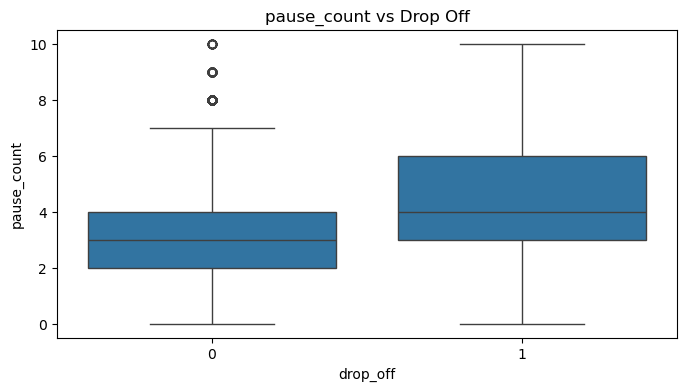



pause_count
            count      mean       std  min  25%  50%  75%   max
drop_off                                                       
0         28367.0  2.863644  1.731141  0.0  2.0  3.0  4.0  10.0
1          4804.0  4.515820  2.009233  0.0  3.0  4.0  6.0  10.0


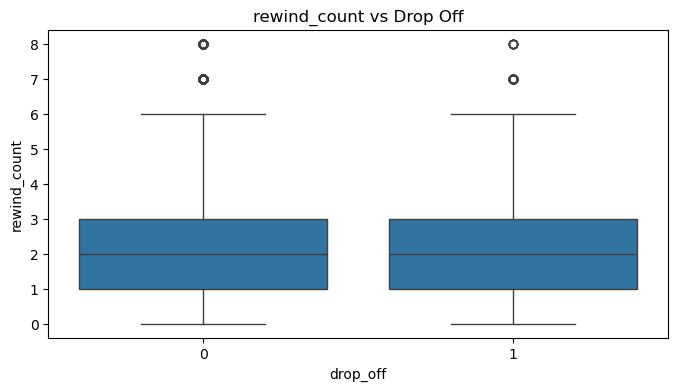



rewind_count
            count      mean       std  min  25%  50%  75%  max
drop_off                                                      
0         28367.0  2.001763  1.553074  0.0  1.0  2.0  3.0  8.0
1          4804.0  2.013739  1.520564  0.0  1.0  2.0  3.0  8.0


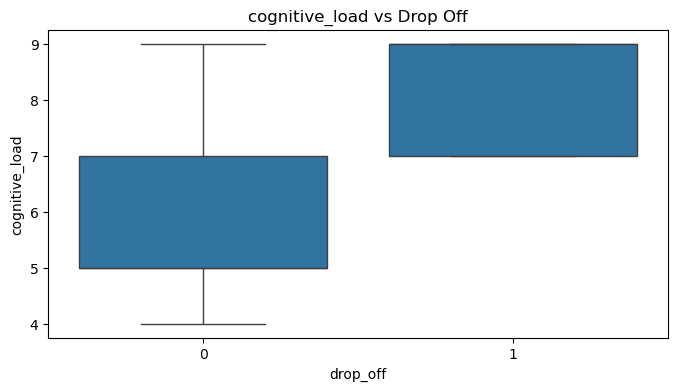



cognitive_load
            count      mean       std  min  25%  50%  75%  max
drop_off                                                      
0         28367.0  5.886065  1.100687  4.0  5.0  5.0  7.0  9.0
1          4804.0  8.026228  0.999760  7.0  7.0  9.0  9.0  9.0


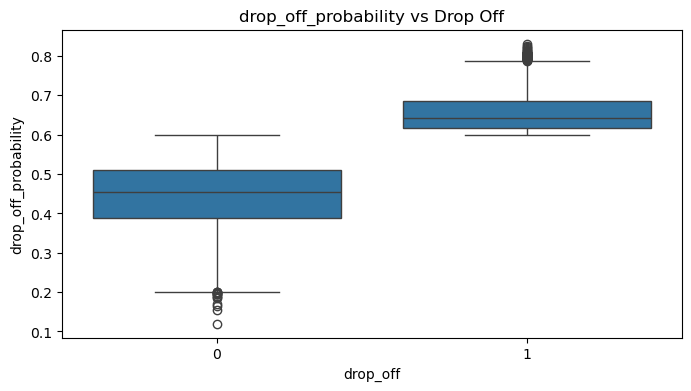



drop_off_probability
            count      mean       std   min    25%    50%    75%    max
drop_off                                                               
0         28367.0  0.448443  0.082943  0.12  0.387  0.453  0.511  0.599
1          4804.0  0.655519  0.048227  0.60  0.616  0.641  0.684  0.831


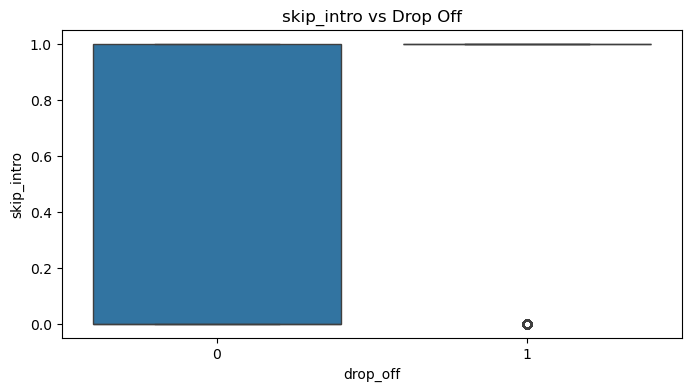



skip_intro
            count      mean       std  min  25%  50%  75%  max
drop_off                                                      
0         28367.0  0.442380  0.496678  0.0  0.0  0.0  1.0  1.0
1          4804.0  0.793714  0.404681  0.0  1.0  1.0  1.0  1.0


In [24]:
num_cols = [
    'release_year',
    'episode_number',
    'episode_duration_min',
    'pacing_score',
    'hook_strength',
    'visual_intensity',
    'avg_watch_percentage',
    'pause_count',
    'rewind_count',
    'cognitive_load',
    'drop_off_probability',
    'skip_intro'
]

for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x='drop_off',y=col,data=df)

    plt.title(f'{col} vs Drop Off')

    plt.show()
    print('\n')
    print('='*60)
    print(col)
    print('='*60)
    print(df.groupby('drop_off')[col].describe())

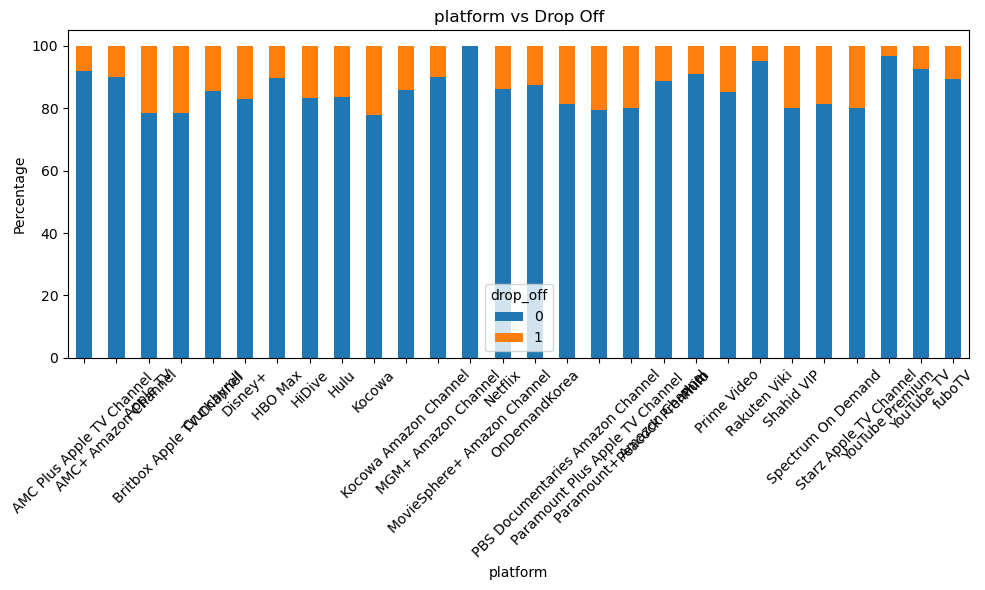

Feature : platform

Percentage Distribution:
drop_off                                   0          1
platform                                               
AMC Plus Apple TV Channel          92.000000   8.000000
AMC+ Amazon Channel                90.000000  10.000000
Apple TV                           78.571429  21.428571
Britbox Apple TV Channel           78.443114  21.556886
Crunchyroll                        85.426009  14.573991
Disney+                            83.056344  16.943656
HBO Max                            89.655172  10.344828
HiDive                             83.333333  16.666667
Hulu                               83.469311  16.530689
Kocowa                             77.777778  22.222222
Kocowa Amazon Channel              85.746102  14.253898
MGM+ Amazon Channel                90.000000  10.000000
MovieSphere+ Amazon Channel       100.000000   0.000000
Netflix                            86.063570  13.936430
OnDemandKorea                      87.547408  12.452592
PBS

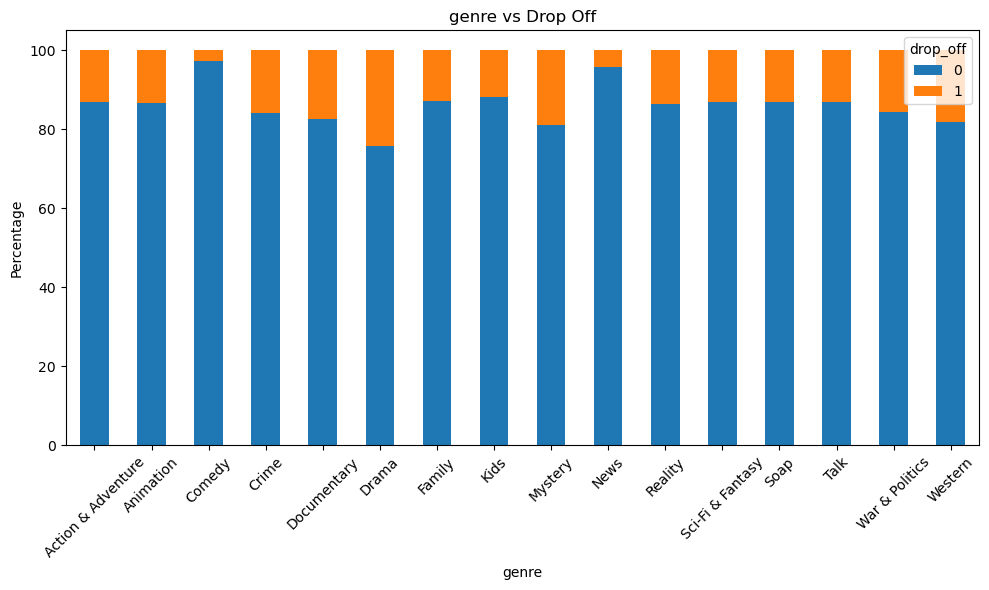

Feature : genre

Percentage Distribution:
drop_off                    0          1
genre                                   
Action & Adventure  86.950053  13.049947
Animation           86.517750  13.482250
Comedy              97.130747   2.869253
Crime               84.125270  15.874730
Documentary         82.666667  17.333333
Drama               75.805926  24.194074
Family              87.019231  12.980769
Kids                88.132911  11.867089
Mystery             81.115880  18.884120
News                95.652174   4.347826
Reality             86.441948  13.558052
Sci-Fi & Fantasy    86.933798  13.066202
Soap                86.826347  13.173653
Talk                86.837030  13.162970
War & Politics      84.313725  15.686275
Western             81.690141  18.309859




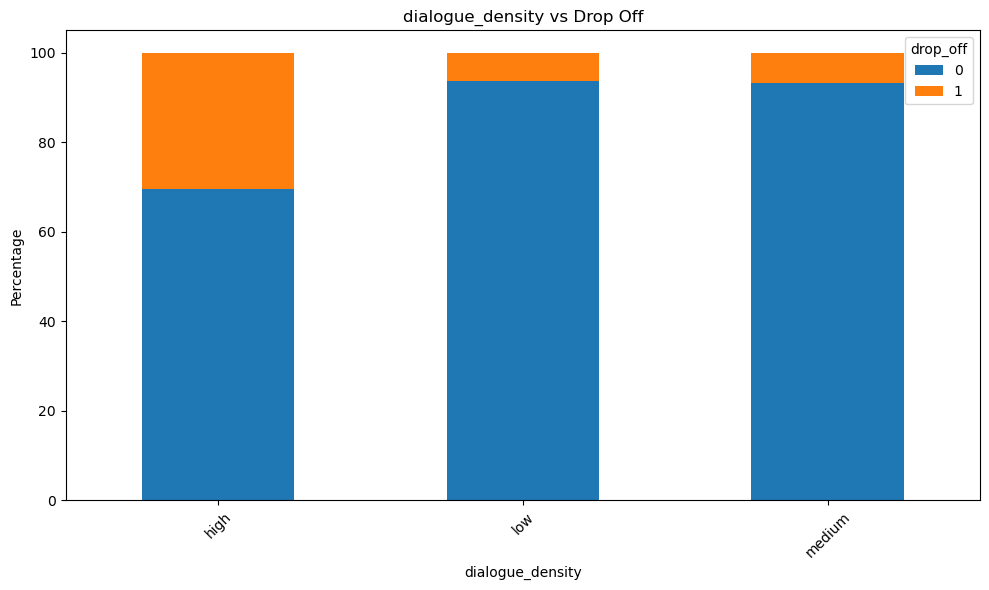

Feature : dialogue_density

Percentage Distribution:
drop_off                  0          1
dialogue_density                      
high              69.635628  30.364372
low               93.720198   6.279802
medium            93.318709   6.681291




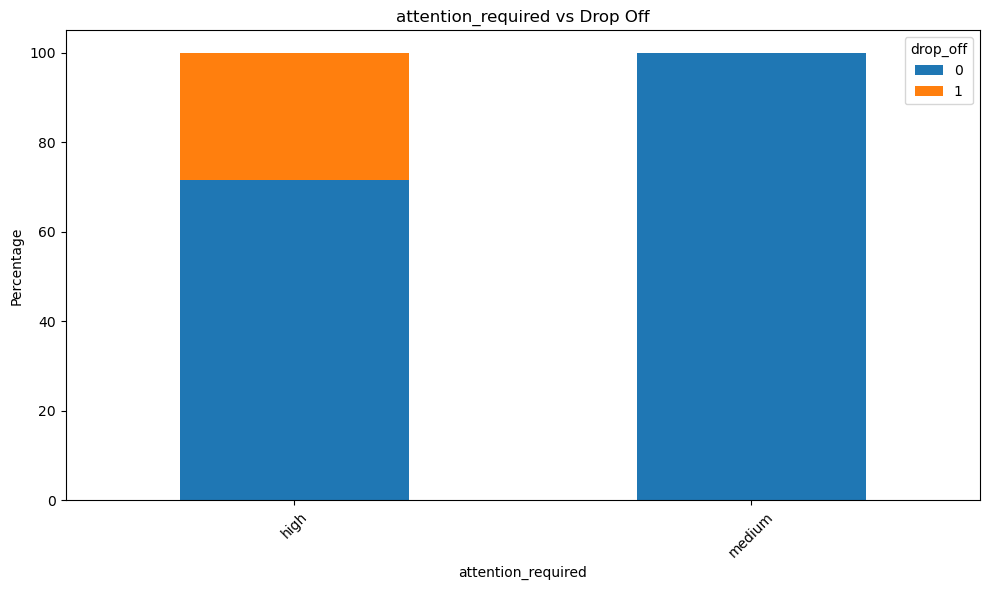

Feature : attention_required

Percentage Distribution:
drop_off                     0          1
attention_required                       
high                 71.536912  28.463088
medium              100.000000   0.000000




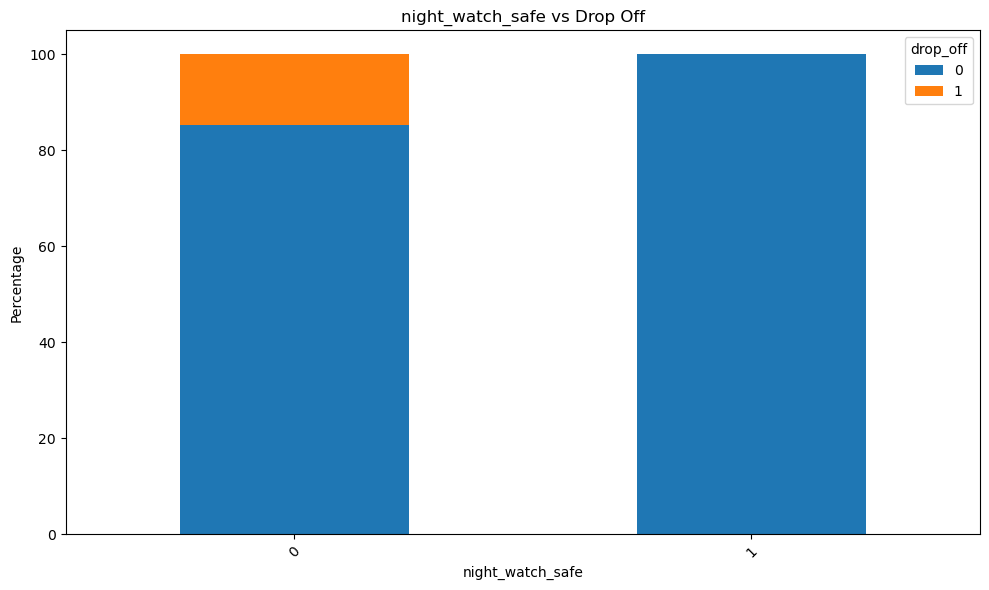

Feature : night_watch_safe

Percentage Distribution:
drop_off                   0          1
night_watch_safe                       
0                  85.283666  14.716334
1                 100.000000   0.000000




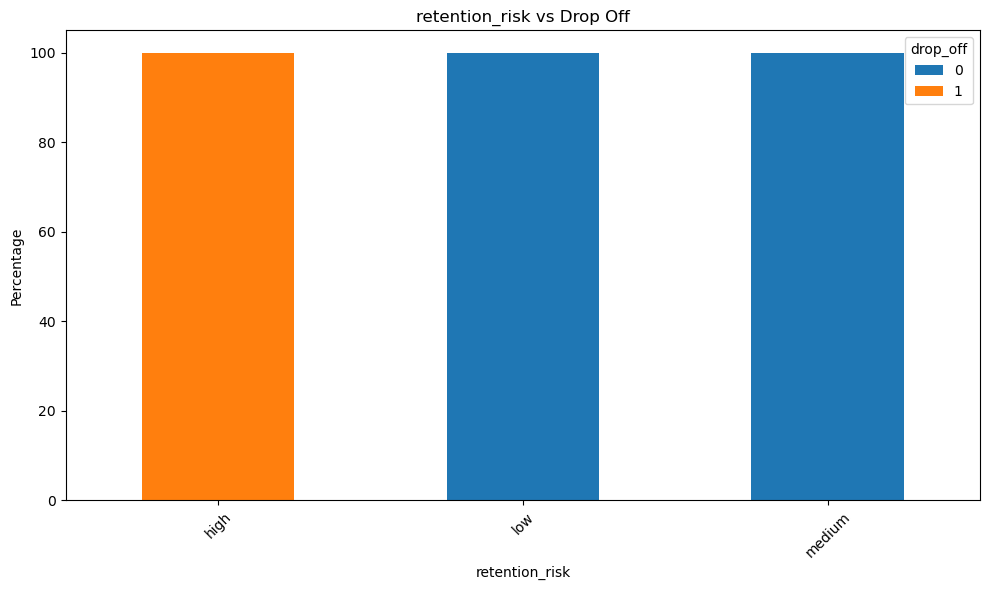

Feature : retention_risk

Percentage Distribution:
drop_off            0      1
retention_risk              
high              0.0  100.0
low             100.0    0.0
medium          100.0    0.0




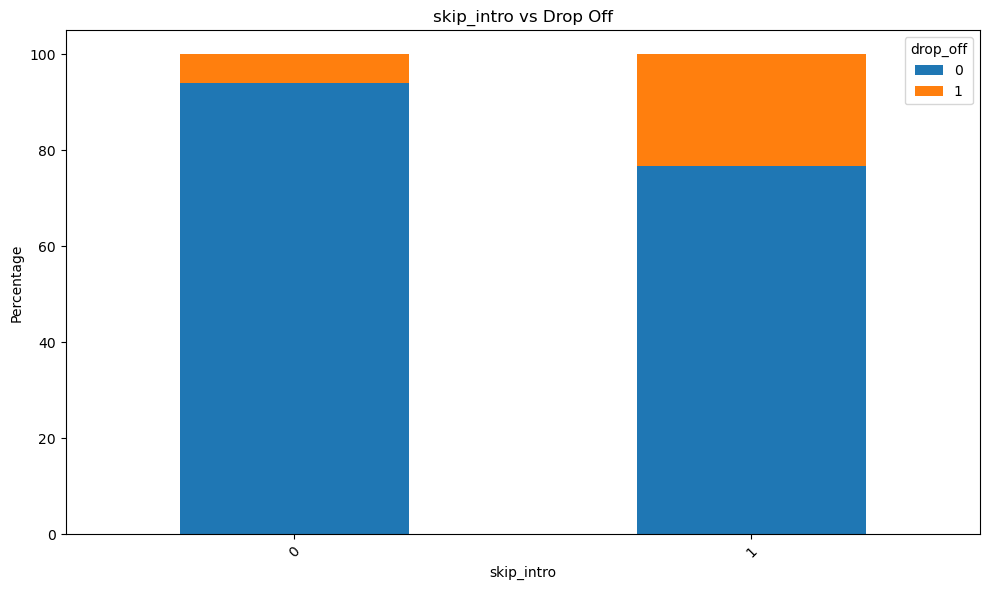

Feature : skip_intro

Percentage Distribution:
drop_off            0          1
skip_intro                      
0           94.104349   5.895651
1           76.696003  23.303997




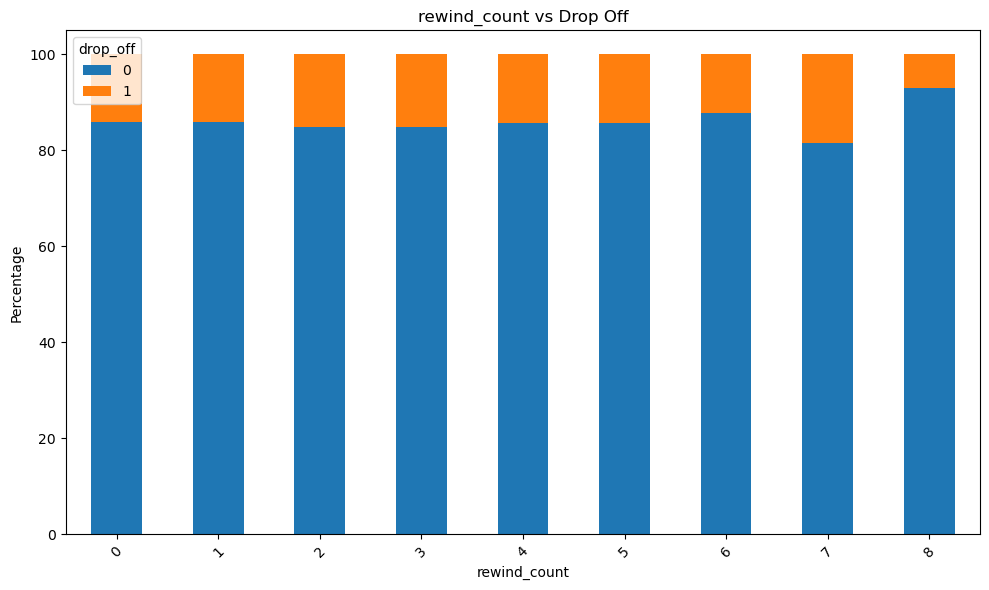

Feature : rewind_count

Percentage Distribution:
drop_off              0          1
rewind_count                      
0             85.993426  14.006574
1             85.928383  14.071617
2             84.917508  15.082492
3             84.932004  15.067996
4             85.633709  14.366291
5             85.796683  14.203317
6             87.847222  12.152778
7             81.589958  18.410042
8             93.069307   6.930693




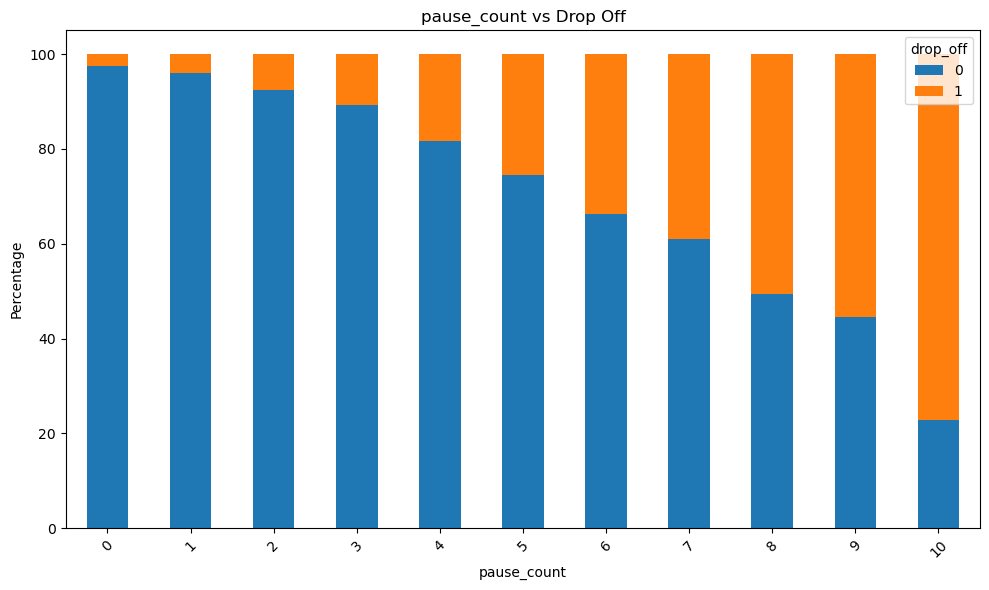

Feature : pause_count

Percentage Distribution:
drop_off             0          1
pause_count                      
0            97.474747   2.525253
1            96.003246   3.996754
2            92.484402   7.515598
3            89.161438  10.838562
4            81.655814  18.344186
5            74.458249  25.541751
6            66.217617  33.782383
7            61.051502  38.948498
8            49.417249  50.582751
9            44.508671  55.491329
10           22.916667  77.083333




In [ ]:
# Define list of categorical columns to analyze
cat_cols = ['platform', 'genre', 'dialogue_density', 'attention_required', 'night_watch_safe', 'retention_risk', 'skip_intro', 'rewind_count', 'pause_count']


for col in cat_cols:

    # Create cross-tabulation table showing drop-off rates by category (normalize by index to get percentages within each category)
    cross_tab = pd.crosstab(df[col], df['drop_off'], normalize='index') * 100

    # Create visualization with single subplot
    fig, ax = plt.subplots(1, 1, figsize=(10,6))

    # Stacked bar chart showing drop-off percentages
    cross_tab.plot(kind='bar', stacked=True, ax=ax)

    # Format subplot
    ax.set_title(f'{col} vs Drop Off')
    ax.set_ylabel('Percentage')
    ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    print('='*70)
    print(f'Feature : {col}')
    print('='*70)

    print('\nPercentage Distribution:')
    print(cross_tab)

    print('\n')

In [26]:
print(df['attention_required'].value_counts())

print(df['night_watch_safe'].value_counts())

attention_required
high      16878
medium    16293
Name: count, dtype: int64
night_watch_safe
0    32644
1      527
Name: count, dtype: int64


In [27]:
# Print cross-tabulation for attention_required vs drop_off
print(pd.crosstab(df['attention_required'], df['drop_off']))

# Print cross-tabulation for night_watch_safe vs drop_off
print(pd.crosstab(df['night_watch_safe'], df['drop_off']))

drop_off                0     1
attention_required             
high                12074  4804
medium              16293     0
drop_off              0     1
night_watch_safe             
0                 27840  4804
1                   527     0


In [28]:
df.drop(
    columns=['show_id', 'title'],
    inplace=True
)

In [29]:
# Drop specified columns from the dataframe
df.drop(columns=['retention_risk', 'drop_off_probability', 'attention_required', 'night_watch_safe'], inplace=True)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33171 entries, 0 to 33170
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   platform              33171 non-null  object
 1   genre                 33171 non-null  object
 2   release_year          33171 non-null  int64 
 3   episode_number        33171 non-null  int64 
 4   episode_duration_min  33171 non-null  int64 
 5   pacing_score          33171 non-null  int64 
 6   hook_strength         33171 non-null  int64 
 7   dialogue_density      33171 non-null  object
 8   visual_intensity      33171 non-null  int64 
 9   avg_watch_percentage  33171 non-null  int64 
 10  pause_count           33171 non-null  int64 
 11  rewind_count          33171 non-null  int64 
 12  skip_intro            33171 non-null  int64 
 13  cognitive_load        33171 non-null  int64 
 14  drop_off              33171 non-null  int64 
dtypes: int64(12), object(3)
memory usage

In [31]:
df.columns

Index(['platform', 'genre', 'release_year', 'episode_number',
       'episode_duration_min', 'pacing_score', 'hook_strength',
       'dialogue_density', 'visual_intensity', 'avg_watch_percentage',
       'pause_count', 'rewind_count', 'skip_intro', 'cognitive_load',
       'drop_off'],
      dtype='object')

In [32]:
# Create mapping dictionary for dialogue density levels
dialogue_map = {'low':1, 'medium':2, 'high':3}

# Map dialogue density to numerical values
df['dialogue_density_num'] = df['dialogue_density'].map(dialogue_map)

# Create content complexity feature by multiplying cognitive load and dialogue density
df['content_complexity'] = df['cognitive_load'] * df['dialogue_density_num']

In [33]:
# Create engagement score by combining hook strength and pacing score
df['engagement_score'] = df['hook_strength'] + df['pacing_score']

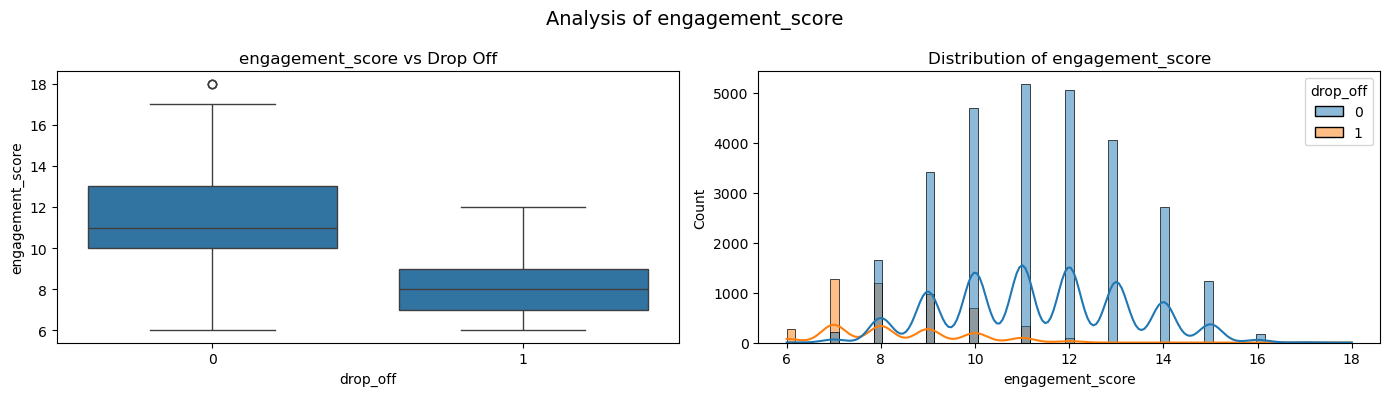


Feature : engagement_score
            count       mean       std  min   25%   50%   75%   max
drop_off                                                           
0         28367.0  11.349491  1.913330  6.0  10.0  11.0  13.0  18.0
1          4804.0   8.405079  1.433204  6.0   7.0   8.0   9.0  12.0


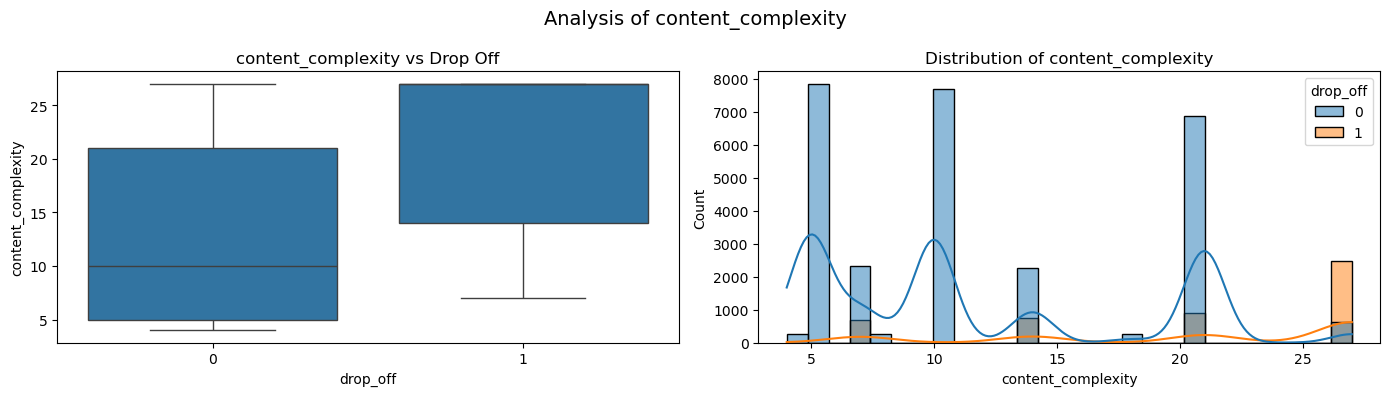


Feature : content_complexity
            count       mean       std  min   25%   50%   75%   max
drop_off                                                           
0         28367.0  11.727500  6.522826  4.0   5.0  10.0  21.0  27.0
1          4804.0  20.979392  7.376789  7.0  14.0  27.0  27.0  27.0


In [ ]:

eng_features = ['engagement_score', 'content_complexity']
for col in eng_features:

    # Create visualization with two subplots side by side
    fig, ax = plt.subplots(1, 2, figsize=(14,4))

    # Left subplot: Boxplot showing feature distribution by drop-off status
    sns.boxplot(x='drop_off', y=col, data=df, ax=ax[0])
    ax[0].set_title(f'{col} vs Drop Off')

    # Right subplot: Histogram with KDE showing feature distribution by drop-off status
    sns.histplot(data=df, x=col, hue='drop_off', kde=True, ax=ax[1])
    ax[1].set_title(f'Distribution of {col}')

    plt.suptitle(f'Analysis of {col}', fontsize=14)
    plt.tight_layout()
    plt.show()
    print('\n' + '='*70)
    print(f'Feature : {col}')
    print('='*70)
    print(df.groupby('drop_off')[col].describe())

In [35]:
df.drop(
    columns=['dialogue_density_num'],
    inplace=True
)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33171 entries, 0 to 33170
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   platform              33171 non-null  object
 1   genre                 33171 non-null  object
 2   release_year          33171 non-null  int64 
 3   episode_number        33171 non-null  int64 
 4   episode_duration_min  33171 non-null  int64 
 5   pacing_score          33171 non-null  int64 
 6   hook_strength         33171 non-null  int64 
 7   dialogue_density      33171 non-null  object
 8   visual_intensity      33171 non-null  int64 
 9   avg_watch_percentage  33171 non-null  int64 
 10  pause_count           33171 non-null  int64 
 11  rewind_count          33171 non-null  int64 
 12  skip_intro            33171 non-null  int64 
 13  cognitive_load        33171 non-null  int64 
 14  drop_off              33171 non-null  int64 
 15  content_complexity    33171 non-null

In [37]:
X = df.drop('drop_off', axis=1)
y = df['drop_off']

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [45]:
# Define feature columns
cat_cols = ['platform', 'genre', 'dialogue_density']
num_cols = ['release_year', 'episode_number', 'episode_duration_min', 'pacing_score', 'hook_strength',
            'visual_intensity', 'pause_count', 'rewind_count', 'skip_intro', 'cognitive_load', 'engagement_score', 'content_complexity', 'avg_watch_percentage']


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [47]:
num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('imputer', SimpleImputer(strategy='median'))])

In [48]:
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [49]:
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols), 
    ('cat', cat_transformer, cat_cols)])

LOGISTIC REGRESSION

Accuracy:
0.99758854559156

ROC AUC:
0.9999602033042628

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5674
           1       1.00      0.99      0.99       961

    accuracy                           1.00      6635
   macro avg       1.00      0.99      1.00      6635
weighted avg       1.00      1.00      1.00      6635


Confusion Matrix:


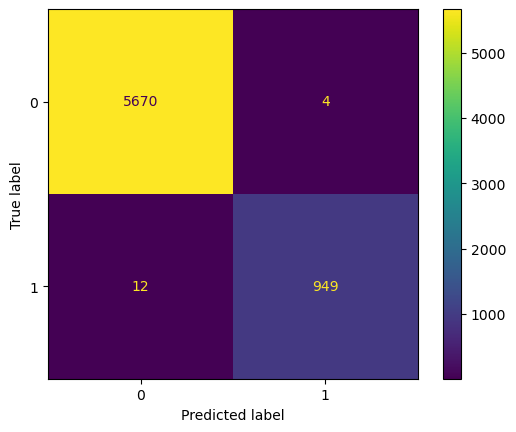

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)

# Pipeline
lr_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model',LogisticRegression(max_iter=1000,random_state=42))
])

# Training
lr_pipeline.fit(X_train, y_train)

# Prediction
y_pred = lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:,1]

# Evaluation
print('='*60)
print('LOGISTIC REGRESSION')
print('='*60)

print('\nAccuracy:')
print(accuracy_score(y_test, y_pred))

print('\nROC AUC:')
print(roc_auc_score(y_test, y_prob))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
plt.show()

In [51]:
# Get feature names after preprocessing
feature_names = lr_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get logistic regression coefficients
coefficients = lr_pipeline.named_steps[
    'model'
].coef_[0]

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Coefficient': abs(coefficients)
})

# Sort by importance
importance_df = importance_df.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

# Display top features
print(importance_df.head(20))

                                           Feature  Coefficient  \
12                       num__avg_watch_percentage   -15.186732   
9                              num__cognitive_load     9.023399   
6                                 num__pause_count     5.003514   
4                               num__hook_strength    -4.674759   
10                           num__engagement_score    -3.071387   
11                         num__content_complexity     2.049872   
57                      cat__dialogue_density_high    -1.717104   
58                       cat__dialogue_density_low     1.518418   
3                                num__pacing_score     1.267735   
31                   cat__platform_Peacock Premium     1.099596   
36                cat__platform_Spectrum On Demand    -0.971124   
40                            cat__platform_fuboTV     0.761691   
19                           cat__platform_HBO Max    -0.678985   
44                                cat__genre_Crime     0.61420

RANDOM FOREST

Accuracy:
0.9891484551620195

ROC AUC:
0.9990714715644357

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5674
           1       0.97      0.96      0.96       961

    accuracy                           0.99      6635
   macro avg       0.98      0.98      0.98      6635
weighted avg       0.99      0.99      0.99      6635


Confusion Matrix:


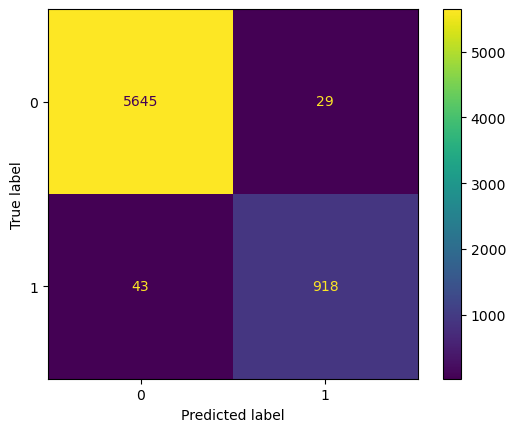

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Pipeline
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        ('model',
         RandomForestClassifier(
             n_estimators=200,
             random_state=42,
             n_jobs=-1
         ))
    ]
)

# Training
rf_pipeline.fit(X_train, y_train)

# Prediction
y_pred = rf_pipeline.predict(X_test)
y_prob = rf_pipeline.predict_proba(X_test)[:,1]

# Evaluation
print('='*60)
print('RANDOM FOREST')
print('='*60)

print('\nAccuracy:')
print(accuracy_score(y_test, y_pred))

print('\nROC AUC:')
print(roc_auc_score(y_test, y_prob))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
plt.show()

In [53]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],

    'Accuracy': [
        0.9976,
        0.9891
    ],

    'ROC_AUC': [
        0.99996,
        0.99907
    ],

    'Recall_DropOff': [
        0.99,
        0.96
    ],

    'F1_DropOff': [
        0.99,
        0.96
    ]
})

comparison

,Model,Accuracy,ROC_AUC,Recall_DropOff,F1_DropOff
0,Logistic Regression,0.9976,0.99996,0.99,0.99
1,Random Forest,0.9891,0.99907,0.96,0.96


In [54]:
# Extract trained RF model
rf_model = rf_pipeline.named_steps['model']

# Feature names
feature_names = (
    rf_pipeline
    .named_steps['preprocessor']
    .get_feature_names_out()
)

# Importance dataframe
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    'Importance',
    ascending=False
)

print(rf_importance.head(20))

                         Feature  Importance
12     num__avg_watch_percentage    0.321955
9            num__cognitive_load    0.107045
10         num__engagement_score    0.103996
11       num__content_complexity    0.095203
6               num__pause_count    0.070928
3              num__pacing_score    0.062382
4             num__hook_strength    0.061335
57    cat__dialogue_density_high    0.027856
1            num__episode_number    0.024078
8                num__skip_intro    0.019968
2      num__episode_duration_min    0.016925
0              num__release_year    0.014356
5          num__visual_intensity    0.013469
7              num__rewind_count    0.012904
59  cat__dialogue_density_medium    0.007629
58     cat__dialogue_density_low    0.007227
46              cat__genre_Drama    0.003905
26         cat__platform_Netflix    0.002708
21            cat__platform_Hulu    0.002570
42          cat__genre_Animation    0.002181


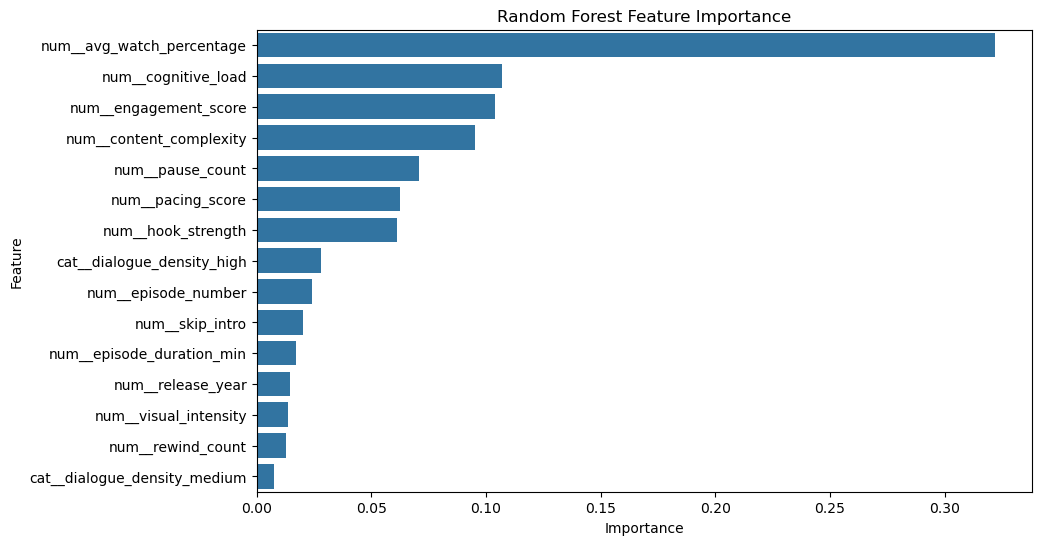

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=rf_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title(
    'Random Forest Feature Importance'
)

plt.show()

In [57]:
!pip install xgboost


   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/69.5 MB 1.2 MB/s eta 0:00:59
    --------------------------------------- 1.3/69.5 MB 2.2 MB/s eta 0:00:31
    --------------------------------------- 1.6/69.5 MB 2.5 MB/s eta 0:00:28
   - -------------------------------------- 2.1/69.5 MB 2.2 MB/s eta 0:00:31
   - -------------------------------------- 2.6/69.5 MB 2.2 MB/s eta 0:00:31
   -- ------------------------------------- 3.7/69.5 MB 2.6 MB/s eta 0:00:26
   -- ------------------------------------- 3.9/69.5 MB 2.7 MB/s eta 0:00:25
   -- ------------------------------------- 5.0/69.5 MB 2.8 MB/s eta 0:00:24
   --- ------------------------------------ 5.8/69.5 MB 2.8 MB/s eta 0:00:23
   --- ------------------------------------ 6.6/69.5 MB 2.9 MB/s eta 0:00:22
   ---- ----------------------------------- 7.3/69.5 MB 3.0 MB/s eta 0:00:21
   ---- -----

In [58]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
xgb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        ('model',
         XGBClassifier(
             n_estimators=200,
             max_depth=6,
             learning_rate=0.1,
             random_state=42,
             eval_metric='logloss'
         ))
    ]
)

xgb_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['release_year',
                                                   'episode_number',
                                                   'episode_duration_min',
                                                   'pacing_score',
                                                   'hook_strength',
                                                   'visual_intensity',
                                                   'pause_count',
                                                   'rewind_count', 'skip_intro',
                                                   'cognitive_load',
                                                   'engagement_score',
                                                   'con...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

XGBOOST

Accuracy:
0.9980406932931424

ROC AUC:
0.999945348316453

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5674
           1       1.00      0.99      0.99       961

    accuracy                           1.00      6635
   macro avg       1.00      0.99      1.00      6635
weighted avg       1.00      1.00      1.00      6635


Confusion Matrix:


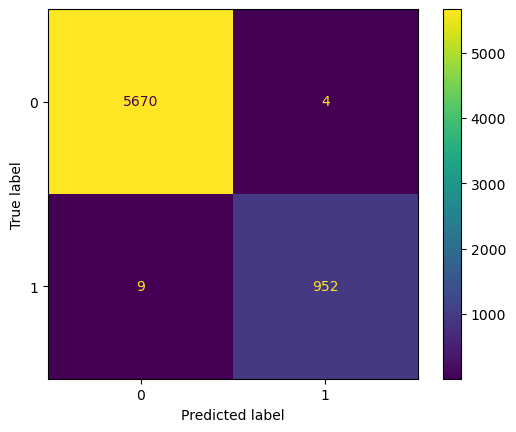

In [59]:
y_pred = xgb_pipeline.predict(X_test)
y_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

print('=' * 60)
print('XGBOOST')
print('=' * 60)

print('\nAccuracy:')
print(accuracy_score(y_test, y_pred))

print('\nROC AUC:')
print(roc_auc_score(y_test, y_prob))

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
plt.show()

print('=' * 60)


In [4]:
# ═══════════════════════════════════════════════════
# DATA QUALITY AUDIT — Why metrics are high
# ═══════════════════════════════════════════════════

print("FINDING 1 — cognitive_load creates a near-perfect rule:")
print(df.groupby('cognitive_load')['drop_off'].mean().round(3))


print("\nFINDING 2 — avg_watch_percentage ranges don't overlap:")
stayed  = df[df['drop_off']==0]
dropped = df[df['drop_off']==1]
print(f"Stayed  : {stayed['avg_watch_percentage'].min()}–{stayed['avg_watch_percentage'].max()}")
print(f"Dropped : {dropped['avg_watch_percentage'].min()}–{dropped['avg_watch_percentage'].max()}")


print("\nFINDING 3 — retention_risk perfectly encodes the target (leakage):")
print(pd.crosstab(df['retention_risk'], df['drop_off']))


print("\nCONCLUSION: Dataset contains synthetic rules.")
print("Metrics (99.3% accuracy, ROC-AUC 0.9999) reflect rule-learning, not real prediction.")
print("Real OTT churn models achieve ROC-AUC 0.75–0.85.")

FINDING 1 — cognitive_load creates a near-perfect rule:
cognitive_load
4    0.000
5    0.000
6    0.000
7    0.170
9    0.796
Name: drop_off, dtype: float64

FINDING 2 — avg_watch_percentage ranges don't overlap:
Stayed  : 34–100
Dropped : 13–55

FINDING 3 — retention_risk perfectly encodes the target (leakage):
drop_off            0     1
retention_risk             
high                0  4804
low               965     0
medium          27402     0

CONCLUSION: Dataset contains synthetic rules.
Metrics (99.3% accuracy, ROC-AUC 0.9999) reflect rule-learning, not real prediction.
Real OTT churn models achieve ROC-AUC 0.75–0.85.


In [ ]:
# CONCLUSION: Data was generated using hard if-else rules:
#   IF cognitive_load IN [4,5,6]      → drop_off = 0 (always)
#   IF cognitive_load == 9            → drop_off = 1 (80% of time)
#   IF avg_watch_percentage > 55      → drop_off = 0 (always)
#   IF avg_watch_percentage < 34      → drop_off = 1 (always)